In [7]:
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np

from network import FCN, Layer
from metrics import confusion_matrix, accuracy, plot_losses, summary

In [8]:
def show_digit(X, y, index):
    plt.imshow(X[index].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y[index])}")
    plt.axis('off')
    plt.show()

In [9]:
def one_hot(y, classes=10):
    encoded = np.zeros((len(y), classes))
    encoded[np.arange(len(y)), y] = 1
    return encoded

FCN initialized


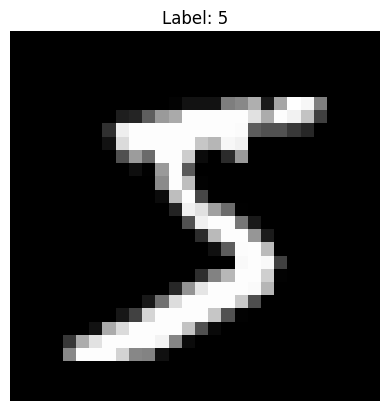

In [10]:
# initialize network with 2 hidden layers
network = FCN([
    Layer(784),
    Layer(128, 'relu'),
    Layer(64, 'relu'),
    Layer(10, 'softmax')
],
learning_rate=0.01,
loss = "cross_entropy")

# load mnist data and split into train and test partitions
(X_train_full, y_train_full), (X_test, y_test) = mnist.load_data()
y_train_full = one_hot(y_train_full)
y_test = one_hot(y_test)

# flatten each image from (28x28) to 784, then normalise to [0,1]
X_train_full = X_train_full.reshape(60000, 784) / 255.0
X_test  = X_test.reshape(10000, 784)  / 255.0

X_train, y_train = X_train_full[:50000], y_train_full[:50000]
X_val, y_val = X_train_full[50000:], y_train_full[50000:]



# test show a digit
show_digit(X_train, y_train, 0)



Epoch 1/50 - Loss: 0.6324
Model improved
Validation Loss: 0.2997
Epoch 2/50 - Loss: 0.2900
Model improved
Validation Loss: 0.2378
Epoch 3/50 - Loss: 0.2375
Model improved
Validation Loss: 0.2057
Epoch 4/50 - Loss: 0.2049
Model improved
Validation Loss: 0.1869
Epoch 5/50 - Loss: 0.1805
Model improved
Validation Loss: 0.1757
Epoch 6/50 - Loss: 0.1616
Model improved
Validation Loss: 0.1551
Epoch 7/50 - Loss: 0.1461
Model improved
Validation Loss: 0.1433
Epoch 8/50 - Loss: 0.1328
Validation Loss: 0.1436
Epoch 9/50 - Loss: 0.1218
Model improved
Validation Loss: 0.1280
Epoch 10/50 - Loss: 0.1123
Model improved
Validation Loss: 0.1265
Epoch 11/50 - Loss: 0.1038
Model improved
Validation Loss: 0.1185
Epoch 12/50 - Loss: 0.0967
Model improved
Validation Loss: 0.1127
Epoch 13/50 - Loss: 0.0901
Model improved
Validation Loss: 0.1081
Epoch 14/50 - Loss: 0.0841
Model improved
Validation Loss: 0.1067
Epoch 15/50 - Loss: 0.0788
Model improved
Validation Loss: 0.1021
Epoch 16/50 - Loss: 0.0740
Validat

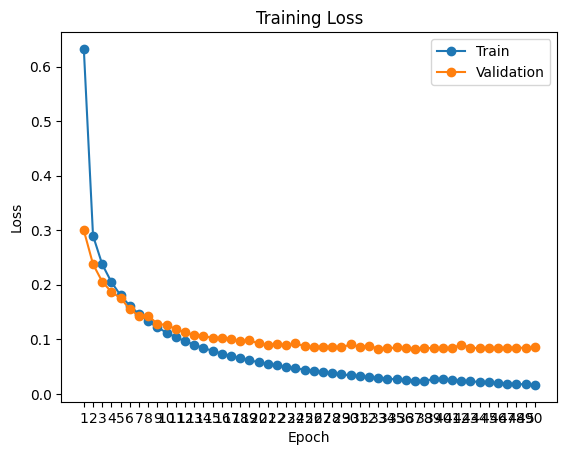

Test Accuracy: 97.67%


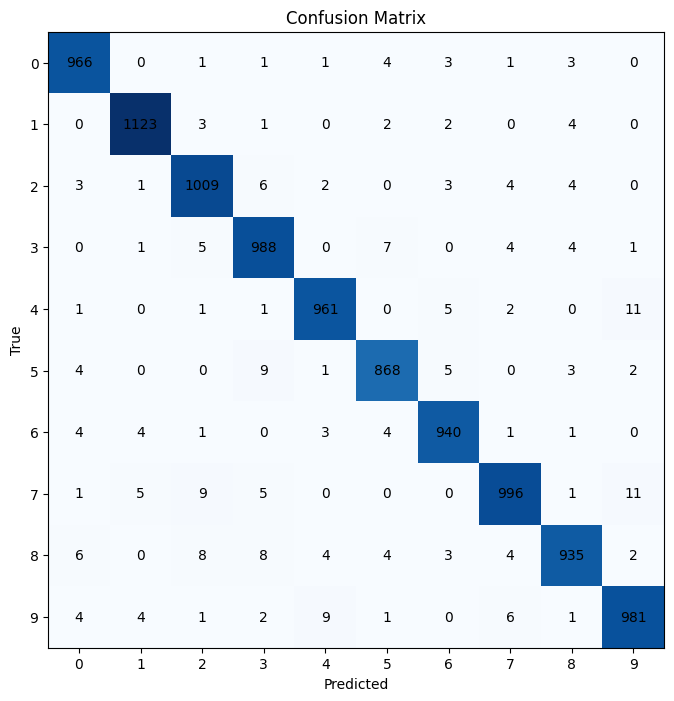

In [11]:
losses = network.train(X_train, y_train, X_val, y_val, epochs=50, batch_size=32)

# display some metrics
plot_losses(losses)
summary(network, X_test, y_test)

In [ ]:
# testing batch_size
batch_sizes = [1, 8, 32, 64, 128, 256]
results = {}

for bs in batch_sizes:
    model = FCN([
        Layer(784),
        Layer(128, 'relu'),
        Layer(10, 'softmax')
    ], loss='cross_entropy', learning_rate=0.01)
    
    model.train(X_train, y_train, epochs=5, batch_size=bs)
    acc = accuracy(model, X_val, y_val)
    results[bs] = acc
    print(f"Batch size {bs}: {acc:.2f}%")

# plot
print("Batch sizes:", batch_sizes)
plt.plot(list(results.keys()), list(results.values()), marker='o')
plt.xscale('log')
plt.xlabel('Batch Size')
plt.ylabel('Validation Accuracy (%)')
plt.title('Accuracy vs Batch Size')
plt.show()

FCN initialized
Epoch 1/5 - Loss: 0.2403
Epoch 2/5 - Loss: 0.1048
Epoch 3/5 - Loss: 0.0753
Epoch 4/5 - Loss: 0.0571
Epoch 5/5 - Loss: 0.0439
Batch size 1: 97.54%
FCN initialized
Epoch 1/5 - Loss: 0.4261
Epoch 2/5 - Loss: 0.2337
Epoch 3/5 - Loss: 0.1823
Epoch 4/5 - Loss: 0.1504
Epoch 5/5 - Loss: 0.1281
Batch size 8: 96.48%
FCN initialized
Epoch 1/5 - Loss: 0.7033
Epoch 2/5 - Loss: 0.3539
Epoch 3/5 - Loss: 0.3018
Epoch 4/5 - Loss: 0.2716
Epoch 5/5 - Loss: 0.2493
Batch size 32: 93.93%
FCN initialized
Epoch 1/5 - Loss: 0.9446
Epoch 2/5 - Loss: 0.4518
Epoch 3/5 - Loss: 0.3763
Epoch 4/5 - Loss: 0.3392
Epoch 5/5 - Loss: 0.3149
Batch size 64: 92.34%
FCN initialized
Epoch 1/5 - Loss: 1.3203
Epoch 2/5 - Loss: 0.6294


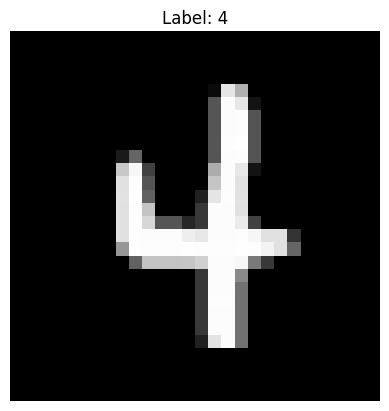

[0.0003 0.0004 0.0253 0.001  0.4456 0.0075 0.0298 0.0732 0.0379 0.379 ]
Prediction: 4


In [ ]:
import random

index = random.randint(0, 9999)
show_digit(X_test, y_test, index)
np.set_printoptions(precision=4, suppress=True)
pred = network.predict(X_test[index])
print(pred)
print("Prediction:", np.argmax(pred))